In [53]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [54]:
df = pd.read_csv('/content/household_power_consumption.csv')
df.head()

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
0,16/12/2006,17:24:00,4.216,0.418,234.84,18.4,0,1,17.0
1,16/12/2006,17:25:00,5.36,0.436,233.63,23,0,1,16.0
2,16/12/2006,17:26:00,5.374,0.498,233.29,23,0,2,17.0
3,16/12/2006,17:27:00,5.388,0.502,233.74,23,0,1,17.0
4,16/12/2006,17:28:00,3.666,0.528,235.68,15.8,0,1,17.0


In [55]:
df.shape

(1048575, 9)

In [56]:
# RENAMED THE COLUMNS FOR UNERSTANDING AND READABILITTY

df.rename(
    columns = {
        'Global_active_power': 'Total_power',
        'Global_reactive_power': 'Power_Wasted',
        'Voltage': 'Voltage',
        'Global_intensity': 'Current',
        'Sub_metering_1': 'Laundry',
        'Sub_metering_2': 'Kitchen',
        'Sub_metering_3': 'Appliances'
         }
    ,inplace = True
)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Date          1048575 non-null  object 
 1   Time          1048575 non-null  object 
 2   Total_power   1048575 non-null  object 
 3   Power_Wasted  1048575 non-null  object 
 4   Voltage       1048575 non-null  object 
 5   Current       1048575 non-null  object 
 6   Laundry       1048575 non-null  object 
 7   Kitchen       1048575 non-null  object 
 8   Appliances    1044506 non-null  float64
dtypes: float64(1), object(8)
memory usage: 72.0+ MB


In [58]:
# SINCE SOME OF THE COLUMNS CONTAIN '?' AS VALUE SO REPALCING THEM WITH Nan AND THEN CONVERTING THE STRING COLUMNS TO FLOAT64

cols = ['Total_power','Power_Wasted','Voltage','Current','Kitchen','Laundry','Appliances']

# Identifing and replacing non-numeric values with NaN

for col in cols:
    df[col] = df[col].replace('?', np.nan)

df[cols] = df[cols].astype('float64')


In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 9 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   Date          1048575 non-null  object 
 1   Time          1048575 non-null  object 
 2   Total_power   1044506 non-null  float64
 3   Power_Wasted  1044506 non-null  float64
 4   Voltage       1044506 non-null  float64
 5   Current       1044506 non-null  float64
 6   Laundry       1044506 non-null  float64
 7   Kitchen       1044506 non-null  float64
 8   Appliances    1044506 non-null  float64
dtypes: float64(7), object(2)
memory usage: 72.0+ MB


In [60]:
df.isnull().sum()

,0
Date,0
Time,0
Total_power,4069
Power_Wasted,4069
Voltage,4069
Current,4069
Laundry,4069
Kitchen,4069
Appliances,4069


In [61]:
# WHY DID I NOT USE MEAN , BECAUSE IN TIME SERIES IT IS BETTER TO CONSIDER THE RECENT PATTERNS SO

df.fillna(method = "ffill"  ,inplace = True)


/tmp/ipython-input-2133384763.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method = "ffill"  ,inplace = True)


In [62]:
df.isnull().sum()

,0
Date,0
Time,0
Total_power,0
Power_Wasted,0
Voltage,0
Current,0
Laundry,0
Kitchen,0
Appliances,0


In [63]:
# MERGE THE COLUMNS DATE AND TIME

df['date_time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


/tmp/ipython-input-2425718857.py:3: UserWarning: Parsing dates in %d/%m/%Y %H:%M:%S format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date_time'] = pd.to_datetime(df['Date'] + ' ' + df['Time'])


In [64]:
df = df.set_index('date_time').drop(columns=['Date', 'Time'])

In [65]:
# SINCE THE DATASET IS TOO BIG WE RESAMPLE IT BY ADDING THE DATA OF 30MIN  TOGETHER

df_new = df.resample('30T').sum()


/tmp/ipython-input-3135257640.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_new = df.resample('30T').sum()


In [66]:
df_new.sample(5)

,Total_power,Power_Wasted,Voltage,Current,Laundry,Kitchen,Appliances
date_time,,,,,,,
2007-02-11 23:00:00,42.714,1.994,7278.35,175.4,0.0,0.0,540.0
2007-03-27 15:30:00,9.418,3.374,7313.36,41.0,0.0,0.0,0.0
2008-09-24 05:00:00,14.338,2.136,7171.21,59.0,0.0,18.0,76.0
2007-08-23 15:30:00,8.374,3.520,7285.98,38.4,0.0,0.0,0.0
2008-09-06 13:30:00,38.768,9.970,7189.50,167.4,6.0,65.0,385.0


In [67]:
# REAMPLING VOLTAGE BY MEAN

voltage_current_resampled = df[['Voltage', 'Current']].resample('30T').mean()

df_new['Voltage'] = voltage_current_resampled['Voltage']

df_new['Current'] = voltage_current_resampled['Current']


/tmp/ipython-input-844131361.py:3: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  voltage_current_resampled = df[['Voltage', 'Current']].resample('30T').mean()


In [68]:
# coverting each column in kwh

df_new['Laundry_kwh'] = df_new['Laundry'] / 1000
df_new['Kitchen_kwh'] = df_new['Kitchen'] / 1000
df_new['Appliances_kwh'] = df_new['Appliances'] / 1000
df_new['Total_energy_kwh'] = df_new['Total_power'] / 60


In [69]:
df_new.drop(columns = ['Total_power','Laundry',	'Kitchen',	'Appliances'],inplace =True)

In [70]:

# SINCE WE AILL BE DOING FORECASTING SO WE NEED DATE AND TIME SO WE EXTRACT THEM FROM THE 'date_time'

df_new['Hour'] = df_new.index.hour
df_new['Weekday'] = df_new.index.weekday
df_new['Month'] = df_new.index.month
df_new['Is_weekend'] = (df_new['Weekday'] >= 5).astype(int)



In [71]:
# REARRANGING THE COLUMNS FOR READABILITY

new_order = [

    'Hour','Weekday','Month','Is_weekend','Power_Wasted','Voltage',
    'Current','Laundry_kwh','Kitchen_kwh','Appliances_kwh','Total_energy_kwh'

    ]

df_new = df_new[new_order]


In [75]:
df_new = df_new.reset_index()

In [76]:
df_new =df_new.drop(columns=['date_time', 'index'])

In [77]:
df_new.columns

Index(['Hour', 'Weekday', 'Month', 'Is_weekend', 'Power_Wasted', 'Voltage',
       'Current', 'Laundry_kwh', 'Kitchen_kwh', 'Appliances_kwh',
       'Total_energy_kwh'],
      dtype='object')

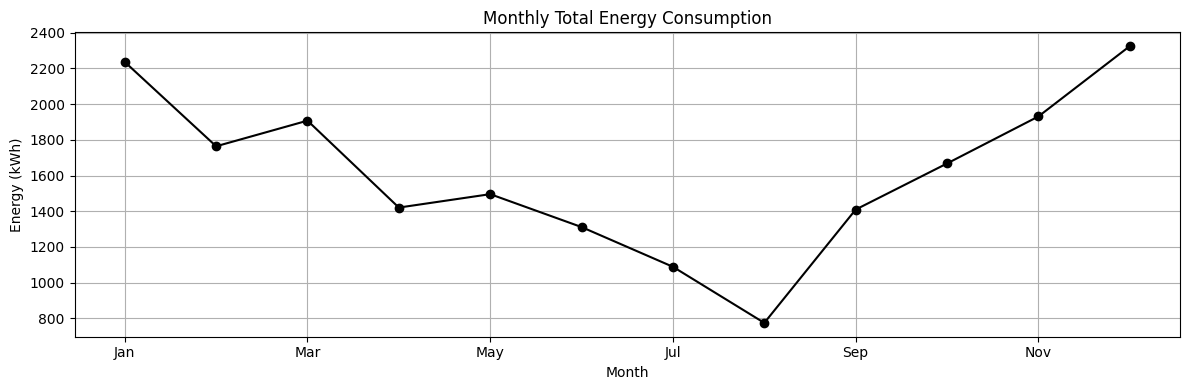

In [78]:

# TO SEE THE TOTAL ENERGY CONSUMPTION MONTH ON MONTH

Month_trends = df_new.groupby(df_new['Month']).sum()

month_names = {
    1: 'Jan', 2: 'Feb', 3: 'Mar', 4: 'Apr', 5: 'May', 6: 'Jun',
    7: 'Jul', 8: 'Aug', 9: 'Sep', 10: 'Oct', 11: 'Nov', 12: 'Dec'
}

Month_trends.index = Month_trends.index.map(month_names)

# Plot
plt.figure(figsize=(12, 4))
Month_trends['Total_energy_kwh'].plot(kind='line', marker='o', color='black')

plt.title('Monthly Total Energy Consumption')
plt.xlabel('Month')
plt.ylabel('Energy (kWh)')
plt.grid(True)
plt.tight_layout()
plt.show()

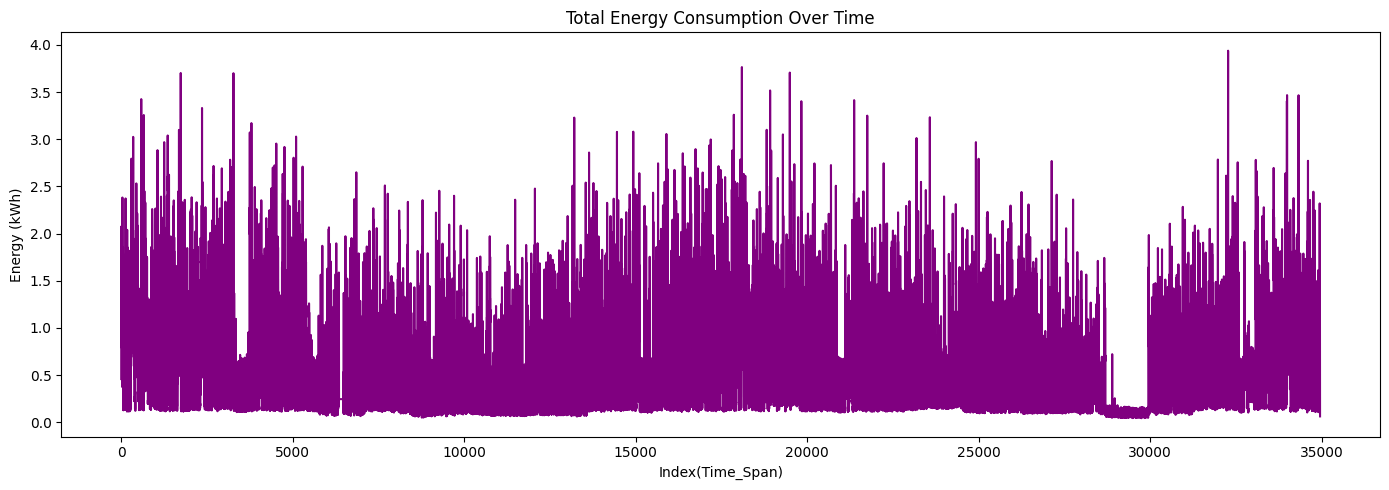

In [79]:
# TOTAL ENERGY CONSUMPTION OVER TIME

plt.figure(figsize=(14, 5))
df_new['Total_energy_kwh'].plot(color='purple')
plt.title('Total Energy Consumption Over Time')
plt.xlabel('Index(Time_Span)')
plt.ylabel('Energy (kWh)')
plt.tight_layout()
plt.show()


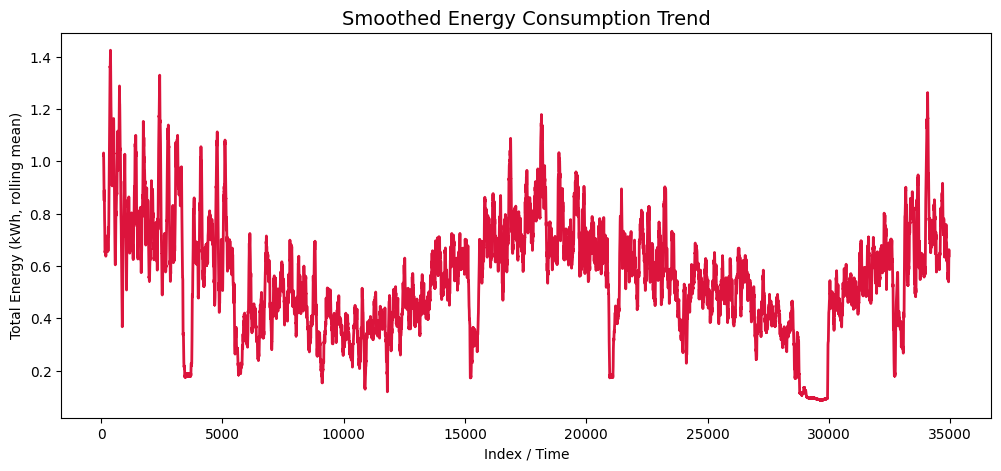

In [80]:
# SMOOTHED ENERGY CONSUMPTION OVER TIME

plt.figure(figsize=(12,5))
df_new["Total_energy_kwh"].rolling(100).mean().plot(color="crimson", linewidth=2)

plt.title("Smoothed Energy Consumption Trend", fontsize=14)
plt.xlabel("Index / Time")
plt.ylabel("Total Energy (kWh, rolling mean)")
plt.show()

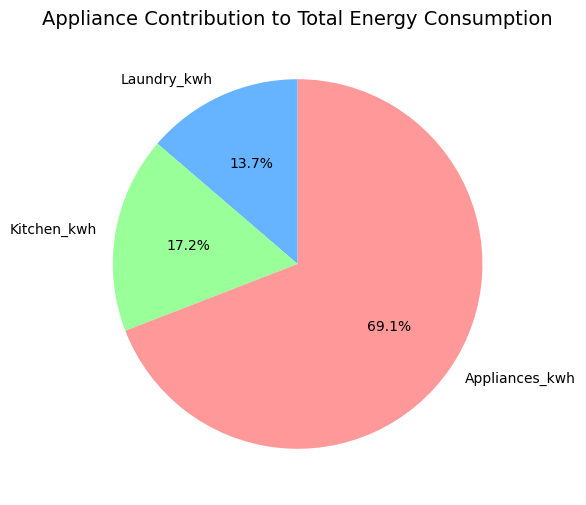

In [81]:
# APPLIANCE CONTRIBUTION TO TOTAL ENERGY CONSUMPTION

appliance_sums = df_new[["Laundry_kwh", "Kitchen_kwh", "Appliances_kwh"]].sum()

plt.figure(figsize=(6,6))
plt.pie(
    appliance_sums,
    labels=appliance_sums.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=["#66b3ff", "#99ff99", "#ff9999"]
)

plt.title("Appliance Contribution to Total Energy Consumption", fontsize=14)
plt.show()


/tmp/ipython-input-1627887814.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


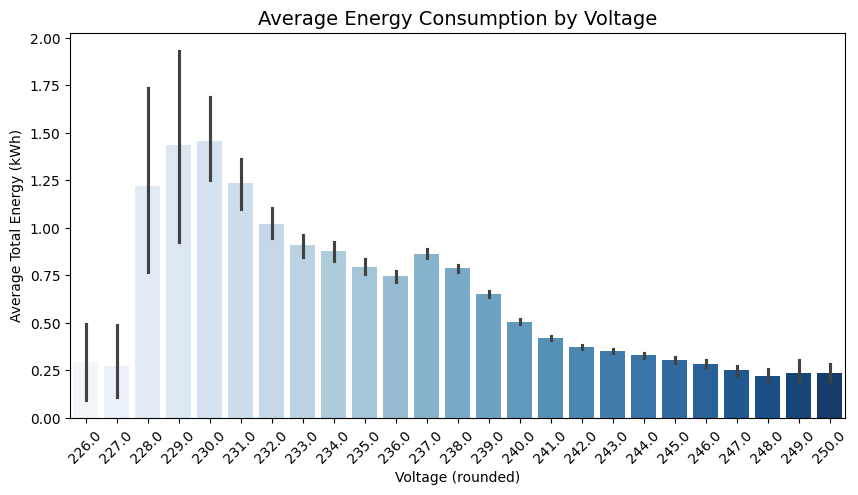

In [82]:
# AVERAGE ENERGY CONSUMPTION BY VOLTAGE

plt.figure(figsize=(10,5))
sns.barplot(
    x=df_new["Voltage"].round(0),   # round voltage to nearest integer
    y=df_new["Total_energy_kwh"],
    estimator="mean",
    palette="Blues"
)

plt.title("Average Energy Consumption by Voltage", fontsize=14)
plt.xlabel("Voltage (rounded)")
plt.ylabel("Average Total Energy (kWh)")
plt.xticks(rotation=45)
plt.show()


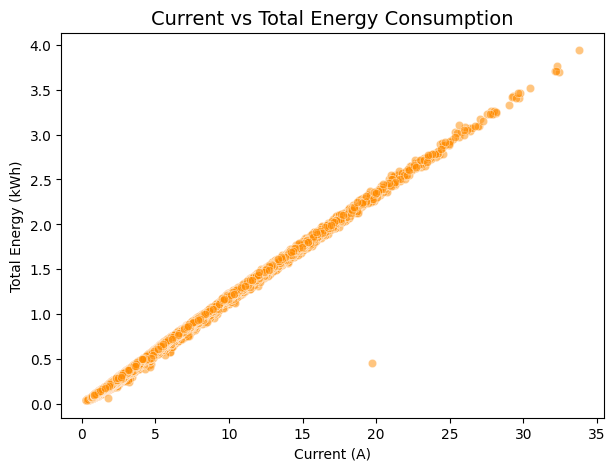

In [83]:
# CURRENT VS TOTAL ENERGY CONSUMPTION

plt.figure(figsize=(7,5))
sns.scatterplot(x="Current", y="Total_energy_kwh", data=df_new, alpha=0.5, color="darkorange")

plt.title("Current vs Total Energy Consumption", fontsize=14)
plt.xlabel("Current (A)")
plt.ylabel("Total Energy (kWh)")
plt.show()


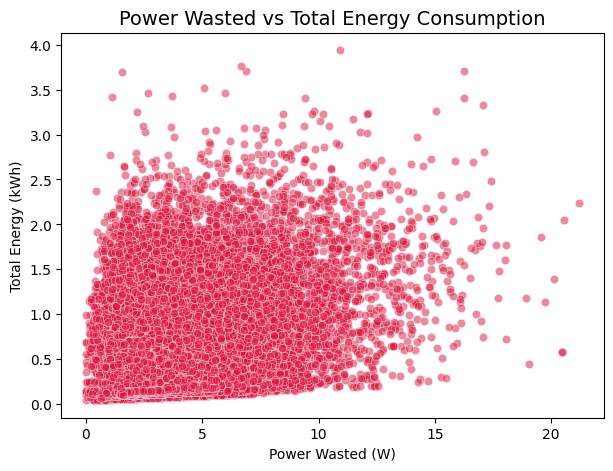

In [84]:
# POWER WASTED VS TOTAL ENERGY CONSUMPTION

plt.figure(figsize=(7,5))
sns.scatterplot(x="Power_Wasted", y="Total_energy_kwh", data=df_new, alpha=0.5, color="crimson")

plt.title("Power Wasted vs Total Energy Consumption", fontsize=14)
plt.xlabel("Power Wasted (W)")
plt.ylabel("Total Energy (kWh)")
plt.show()


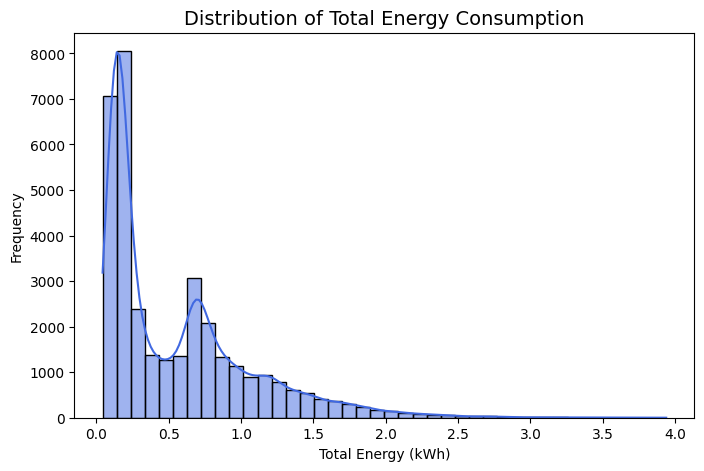

In [85]:
# DISTRIBUTION OF TOTAL ENERGY CONSUMPTION

plt.figure(figsize=(8,5))
sns.histplot(df_new["Total_energy_kwh"], bins=40, kde=True, color="royalblue")

plt.title("Distribution of Total Energy Consumption", fontsize=14)
plt.xlabel("Total Energy (kWh)")
plt.ylabel("Frequency")
plt.show()


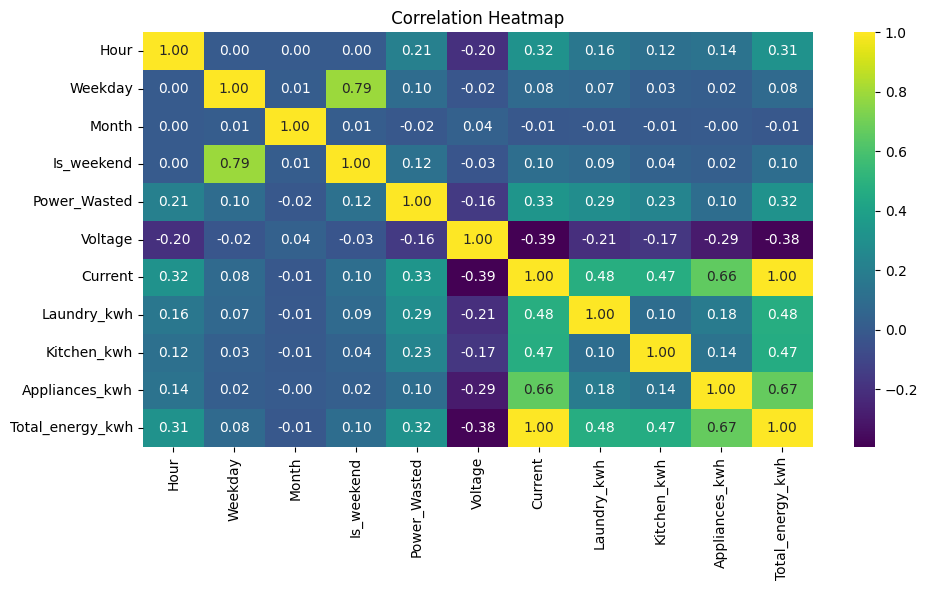

In [86]:
#  THE CORRELATION HEATMAP OF ALL THE COLUMNS

plt.figure(figsize=(10, 6))
sns.heatmap(df_new.corr(numeric_only=True), annot=True, cmap='viridis', fmt='.2f')
plt.title(' Correlation Heatmap ')
plt.tight_layout()
plt.show()


/tmp/ipython-input-4135130621.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="Hour", y="Total_energy_kwh", data=df_new, palette="viridis", fliersize=2)


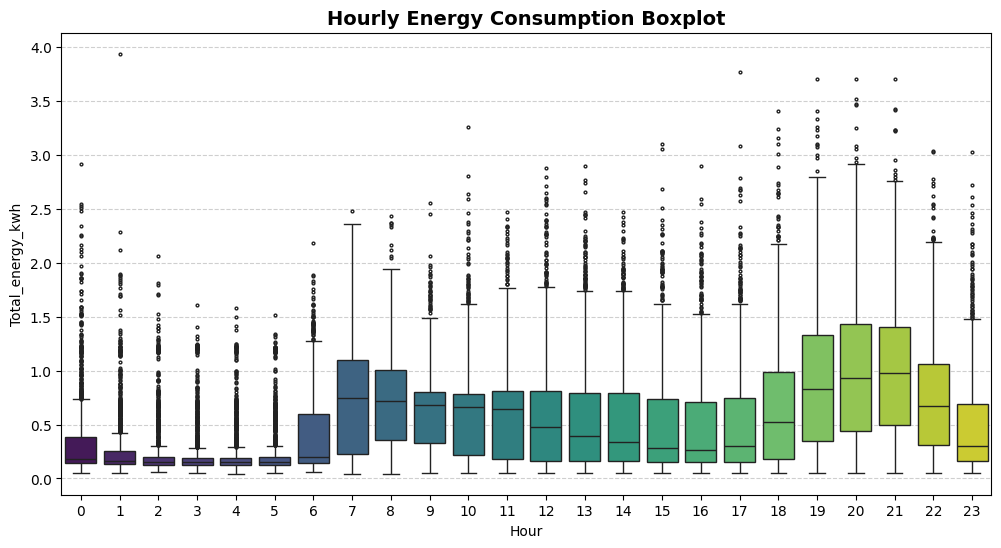

In [87]:
# HOURLY ENERGY CONSUMPTION

plt.figure(figsize=(12,6))
sns.boxplot(x="Hour", y="Total_energy_kwh", data=df_new, palette="viridis", fliersize=2)
plt.title("Hourly Energy Consumption Boxplot", fontsize=14, weight="bold")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


/tmp/ipython-input-2131797044.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Hour", y="Total_energy_kwh", data=df_new, estimator="mean", palette="coolwarm")


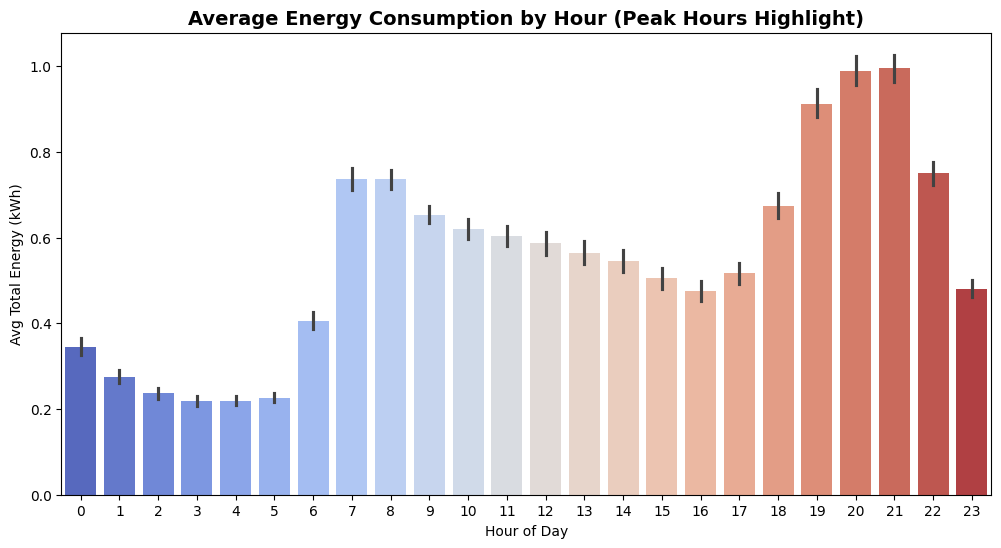

In [88]:
# AVERAGE ENERGY CONSUMPTION BY HOUR

plt.figure(figsize=(12,6))
sns.barplot(x="Hour", y="Total_energy_kwh", data=df_new, estimator="mean", palette="coolwarm")
plt.title("Average Energy Consumption by Hour (Peak Hours Highlight)", fontsize=14, weight="bold")
plt.ylabel("Avg Total Energy (kWh)")
plt.xlabel("Hour of Day")
plt.show()


# **Why so many outliers ?**

In energy consumption data, especially hourly, outliers are expected because:

Someone might use heavy appliances suddenly (e.g., heater, oven, AC).

Some days (e.g., holidays or weekends) see unusual behavior.

There might be measurement spikes or sensor errors too.






---



 **NOW WE ARE READY WITH OUR DATA AND THE NEXT STEP WOULD BE MODELLING ,BUT  SINCE THIS IS FORECASTING WE NEED LAG'S SO WE CREATE THEM**

In [89]:
# WE CREATE A COPY AND THEN INTRODUCE LAGS IN IT AS OUR ORIGINAL DATA SHOULDN'T BE MODIFIED
# ALSO WE CREATE 3 LAG REPRESENTING THE LAST 3 HR VALUES

df_copy= df_new.copy()

df_copy['lag_1'] = df_copy['Total_energy_kwh'].shift(1)
df_copy['lag_2'] = df_copy['Total_energy_kwh'].shift(2)
df_copy['lag_3'] = df_copy['Total_energy_kwh'].shift(3)
df_copy['lag_4'] = df_copy['Total_energy_kwh'].shift(4)
df_copy['lag_5'] = df_copy['Total_energy_kwh'].shift(5)
df_copy['lag_6'] = df_copy['Total_energy_kwh'].shift(6)



df_copy['Voltage_lag1'] = df_copy['Voltage'].shift(1)
df_copy['Voltage_lag2'] = df_copy['Voltage'].shift(2)

df_copy['Current_lag1'] = df_copy['Current'].shift(1)
df_copy['Current_lag2'] = df_copy['Current'].shift(2)



df_copy.dropna(inplace=True)

In [90]:

df_copy.reset_index(inplace = True)
df_copy.drop(columns = ['index'],inplace = True)
df_copy.head()


,Hour,Weekday,Month,Is_weekend,Power_Wasted,Voltage,Current,Laundry_kwh,Kitchen_kwh,Appliances_kwh,...,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,Voltage_lag1,Voltage_lag2,Current_lag1,Current_lag2
0,20,5,12,1,1.618,233.224667,14.066667,0.0,0.000,0.500,...,1.668033,1.732200,1.659800,1.972400,2.075000,0.458733,232.711000,233.754000,14.260000,14.746667
1,20,5,12,1,2.888,234.918333,13.766667,0.0,0.000,0.507,...,1.649300,1.668033,1.732200,1.659800,1.972400,2.075000,233.224667,232.711000,14.066667,14.260000
2,21,5,12,1,1.900,237.351667,12.946667,0.0,0.000,0.517,...,1.619267,1.649300,1.668033,1.732200,1.659800,1.972400,234.918333,233.224667,13.766667,14.066667
3,21,5,12,1,2.700,236.965667,13.146667,0.0,0.025,0.516,...,1.516167,1.619267,1.649300,1.668033,1.732200,1.659800,237.351667,234.918333,12.946667,13.766667
4,22,5,12,1,1.122,237.728333,10.886667,0.0,0.008,0.266,...,1.540300,1.516167,1.619267,1.649300,1.668033,1.732200,236.965667,237.351667,13.146667,12.946667


**WE WILL BE USING THE FOLLOWING MODELS HERE**

1.   KNN
2.   RANDOM FOREST
3.   GRADIENT BOOST
4.   XGBOOST




**SINCE XGBOOST , GRADIENT BOOST , RANDOM FOREST DON'T REQUIRE SCALING BUT FOR KNN WE WILL WORK WITH IT**





# **1.KNN(K-NEAREST NEIGHBOURS)**

In [92]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

In [93]:

# pick only numeric columns (exclude target if you want to predict it later)

df_knn = df_copy.copy()

numeric_cols = df_knn.select_dtypes(include=['int64', 'float64']).columns
numeric_cols = numeric_cols.drop('Total_energy_kwh')

scaler = StandardScaler()
df_knn[numeric_cols] = scaler.fit_transform(df_knn[numeric_cols])

df_knn.head()



,Hour,Weekday,Month,Is_weekend,Power_Wasted,Voltage,Current,Laundry_kwh,Kitchen_kwh,Appliances_kwh,...,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,Voltage_lag1,Voltage_lag2,Current_lag1,Current_lag2
0,20,5,12,1.580822,-0.851092,-2.151783,2.182619,-0.269011,-0.279226,1.402340,...,2.187612,2.313242,2.171008,2.783863,2.984764,-0.184858,-2.315941,-1.981961,2.227480,2.340717
1,20,5,12,1.580822,-0.294322,-1.609697,2.112655,-0.269011,-0.279226,1.432764,...,2.150862,2.187374,2.313018,2.170767,2.783556,2.984813,-2.151545,-2.315749,2.182395,2.227235
2,21,5,12,1.580822,-0.727463,-0.830868,1.921419,-0.269011,-0.279226,1.476226,...,2.091945,2.150627,2.187158,2.312764,2.170518,2.783604,-1.609499,-2.151362,2.112436,2.182153
3,21,5,12,1.580822,-0.376742,-0.954414,1.968062,-0.269011,-0.120862,1.471880,...,1.889692,2.091714,2.150413,2.186915,2.312501,2.170562,-0.830727,-1.609343,1.921212,2.112198
4,22,5,12,1.580822,-1.068539,-0.710309,1.440998,-0.269011,-0.228549,0.385327,...,1.937035,1.889475,2.091504,2.150174,2.186665,2.312546,-0.954264,-0.830610,1.967852,1.920988


In [94]:
from sklearn.neighbors import KNeighborsRegressor

X = df_knn.drop(columns=['Total_energy_kwh','Voltage' , 'Current'])
y = df_knn['Total_energy_kwh']


X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42 ,shuffle = False)


knn = KNeighborsRegressor(n_neighbors=11)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

rmse_knn =  np.sqrt(mean_squared_error(y_test, y_pred ))
mae_knn =  mean_absolute_error(y_test, y_pred)
r2_knn  = r2_score(y_test, y_pred)


print(f"KNN RMSE: {rmse_knn:.4f}")
print(f"KNN MAE: {mae_knn:.4f}")
print(f"KNN R²: {r2_knn:.4f}")


KNN RMSE: 0.1823
KNN MAE: 0.1153
KNN R²: 0.8490


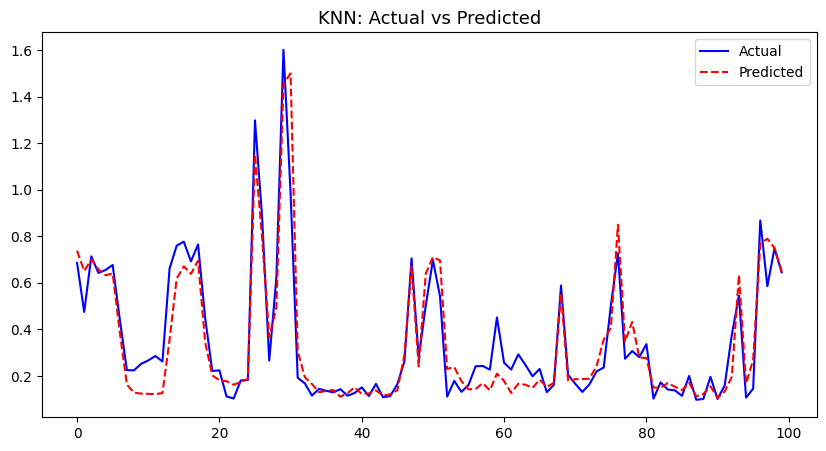

In [98]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred[:100], label="Predicted", color="red", linestyle="--")
plt.title("KNN: Actual vs Predicted", fontsize=13)
plt.legend()
plt.show()





---



# **2) RANDOM FOREST**

In [96]:
from sklearn.ensemble import RandomForestRegressor


df_rf = df_copy.copy()

x = df_rf.drop(columns=['Total_energy_kwh', 'Voltage', 'Current'])  # Drop original columns
y = df_rf['Total_energy_kwh']

x_train , x_test , y_train , y_test = train_test_split(x,y ,test_size=0.2 , shuffle = False )

# HERE SHUFFLE MEANS THAT WE DONT WANT RANDOM ROWS WE WANT THE SEQUENCE OF ROWS IN A ORDER SINCE IT IS TIME SERIES DATA SO ORDER MATTERS A LOT


rf = RandomForestRegressor(n_estimators = 200 ,max_depth = 10 , random_state =42)
rf.fit(x_train , y_train)


y_pred_rf = rf.predict(x_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_squared_error(y_test , y_pred_rf)

print(f"Random Forest RMSE: {rmse_rf:.4f}")
print(f"Random Forest MAE: {mae_rf:.4f}")
print(f"Random Forest R²: {r2_rf:.4f}")

Random Forest RMSE: 0.1617
Random Forest MAE: 0.0262
Random Forest R²: 0.8811


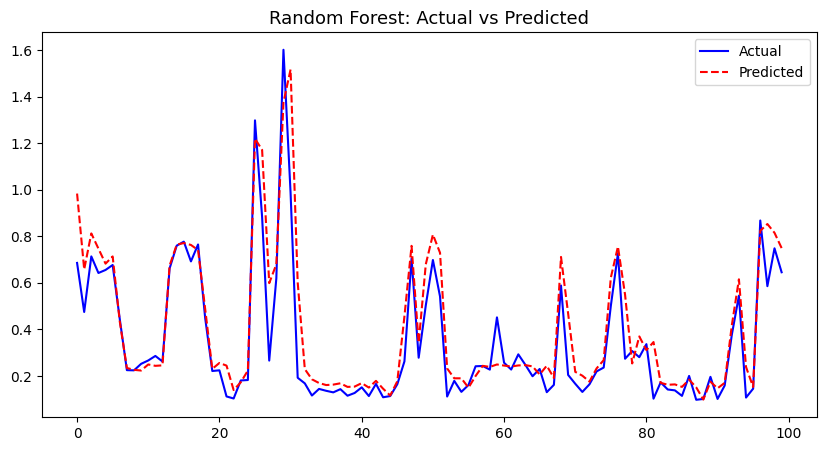

In [99]:
# ACTUAL VS PREDICTED

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:100], label="Actual", color="blue")
plt.plot(y_pred_rf[:100], label="Predicted", color="red", linestyle="--")
plt.title("Random Forest: Actual vs Predicted", fontsize=13)
plt.legend()
plt.show()




---



# **3)GRADIENT** **BOOSTING**

In [100]:
from sklearn.ensemble import GradientBoostingRegressor

df_gb = df_copy.copy()

# Train-test split (no shuffling for time series)

x = df_gb.drop(columns=['Total_energy_kwh','Voltage','Current'])
y = df_gb['Total_energy_kwh']


x_train_gb, x_test_gb, y_train_gb, y_test_gb = train_test_split(x, y, test_size=0.3, shuffle=False)


gb = GradientBoostingRegressor( n_estimators=200 , learning_rate=0.05, max_depth=6, random_state=42)
gb.fit(x_train_gb, y_train_gb)

y_pred_gb = gb.predict(x_test_gb)


rmse_gb = np.sqrt(mean_squared_error(y_test_gb, y_pred_gb))
mae_gb = mean_absolute_error(y_test_gb, y_pred_gb)
r2_gb = r2_score(y_test_gb, y_pred_gb)

print(f"Gradient Boost MSE: {rmse_gb:.4f}")
print(f"Gradient Boost MAE: {mae_gb:.4f}")
print(f"Gradient Boost R² Score: {r2_gb:.4f}")



Gradient Boost MSE: 0.1401
Gradient Boost MAE: 0.0932
Gradient Boost R² Score: 0.9024


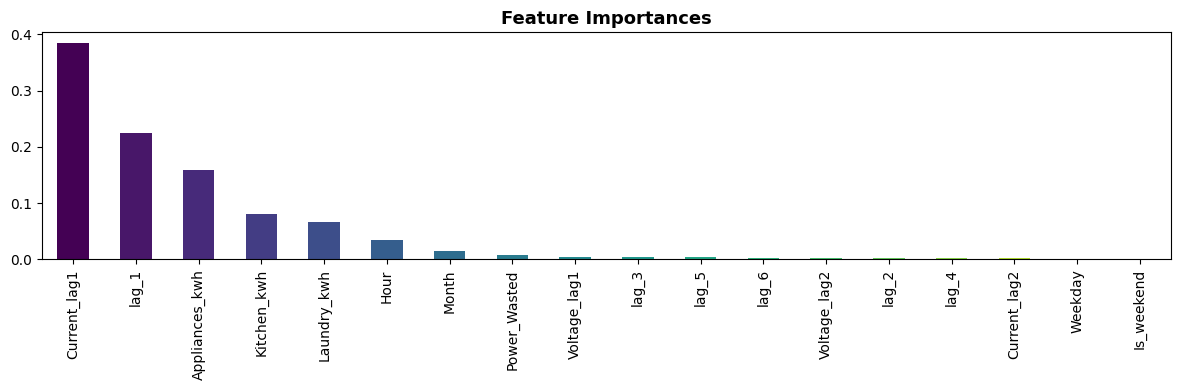

In [101]:
# SEEING WHICH FEATURES ARE IMPORTANT

feature_importance = pd.Series(gb.feature_importances_, index=x.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(12,4))
feature_importance.plot(kind="bar", color=plt.cm.viridis(np.linspace(0,1,len(feature_importance))))
plt.title("Feature Importances", fontsize=13, weight="bold")
plt.tight_layout()
plt.show()





---



# 4) **XGBOOST**

In [102]:
# adding rolling means and more lags..

df_copy['rolling_mean_3'] = df_copy['Total_energy_kwh'].shift(1).rolling(6).mean()
df_copy['rolling_mean_6'] = df_copy['Total_energy_kwh'].shift(1).rolling(12).mean()
df_copy['rolling_mean_12'] = df_copy['Total_energy_kwh'].shift(1).rolling(24).mean()



df_copy['lag_7'] = df_copy['Total_energy_kwh'].shift(7)
df_copy['lag_8'] = df_copy['Total_energy_kwh'].shift(8)
df_copy['lag_9'] = df_copy['Total_energy_kwh'].shift(9)
df_copy['lag_10'] = df_copy['Total_energy_kwh'].shift(10)
df_copy['lag_11'] = df_copy['Total_energy_kwh'].shift(11)
df_copy['lag_12'] = df_copy['Total_energy_kwh'].shift(12)

df_copy.dropna(inplace = True)

In [103]:
import xgboost as xgb
from xgboost import XGBRegressor

In [104]:

df_xgb = df_copy.copy()


x1 = df_xgb.drop(columns=['Total_energy_kwh','Voltage','Current'])
y1 = df_xgb['Total_energy_kwh']


x_train1,x_test1 , y_train1,y_test1 = train_test_split( x1 , y1 , test_size=0.2 , random_state=42 , shuffle = False)


xgb = XGBRegressor(n_estimators= 2500 , random_state =42 , max_depth =7 , learning_rate = 0.04, subsample=0.8, colsample_bytree=0.7,gamma=0.4,
                      reg_alpha=1.0 , reg_lambda=2.0, objective='reg:squarederror')


xgb.fit(x_train1,y_train1)

y_pred_xgb = xgb.predict(x_test1)

rmse_xgb = np.sqrt((mean_squared_error(y_test1,y_pred_xgb)))
mae_xgb = mean_absolute_error(y_test1,y_pred_xgb)
r2_xgb = r2_score(y_test1 , y_pred_xgb)

print(f"XGBOOST RMSE: {rmse_xgb:.4f}")
print(f"XGBOOST MAE: {mae_xgb:.4f}")
print(f"XGBOOST R²: {r2_xgb:.4f}")

XGBOOST RMSE: 0.1413
XGBOOST MAE: 0.0882
XGBOOST R²: 0.9093


In [105]:
# TO CHECK WHETHER  OVERFIITNG TAKES PLACE ,
# TO PREDICT ON THE TRAIN AND TEST DATA AS WELL

y_train_pred = xgb.predict(x_train1)
train_r2 = r2_score(y_train1, y_train_pred)

# On test data
test_r2 = r2_score(y_test1, y_pred_xgb)

print(f"XGBOOST Train R²: {train_r2:.4f}")
print(f"XGBOOST Test R²: {test_r2:.4f}")


XGBOOST Train R²: 0.9242
XGBOOST Test R²: 0.9093


In [106]:
# XGBoost Results

rmse = np.sqrt(mean_squared_error(y_test1, y_pred_xgb))
mae = mean_absolute_error(y_test1, y_pred_xgb)
r2 = r2_score(y_test1, y_pred_xgb)

print("🔹 XGBoost Performance")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"MAE : {mae_xgb:.4f}")
print(f"R²  : {r2_xgb:.4f}")



# Naive Baseline

y_naive_pred = y_test1.shift(1).dropna()
y_true = y_test1.iloc[1:]


naive_rmse = np.sqrt(mean_squared_error(y_true, y_naive_pred))
naive_mae = mean_absolute_error(y_true, y_naive_pred)
naive_r2 = r2_score(y_true, y_naive_pred)


print("\n🔹 Naive Baseline Performance")
print(f"RMSE: {naive_rmse:.4f}")
print(f"MAE : {naive_mae:.4f}")
print(f"R²  : {naive_r2:.4f}")


🔹 XGBoost Performance
RMSE: 0.1413
MAE : 0.0882
R²  : 0.9093

🔹 Naive Baseline Performance
RMSE: 0.2820
MAE : 0.1643
R²  : 0.6387


# **Naive R²**:
Naive R² measures how well a simple "tomorrow = today" forecast performs, serving as a baseline to judge if the fancy model is actually smart or just exploiting trivial patterns.



# **Interpretation:**

**High naive R² (>80%)**: The data is predictable by default  

**Low naive R² (<50%)**: The time series is noisy/volatile, so any model improving thia, adds real value.

**My Case**: Naive R² of 64% → My XGBoost’s 91% is meaningfully better, not just overfitting.

<Figure size 1200x800 with 0 Axes>

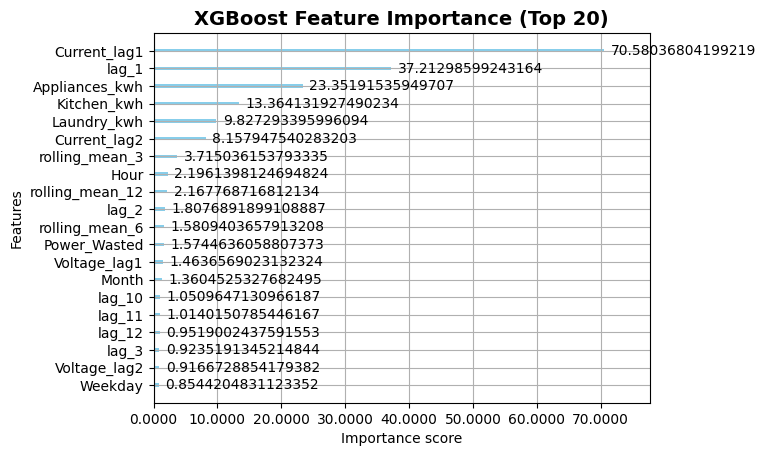

In [107]:
# THIS SHOWS HOW MUCH MY COLUMNS ARE RELATED TO MY XGBOOST MODEL PERFORMANCE

from xgboost import plot_importance

plt.figure(figsize=(12,8))
ax = plot_importance(xgb,
                     max_num_features=20,
                     importance_type="gain",
                     color="skyblue")
plt.title("XGBoost Feature Importance (Top 20)", fontsize=14, weight="bold")

ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.4f}"))

plt.show()



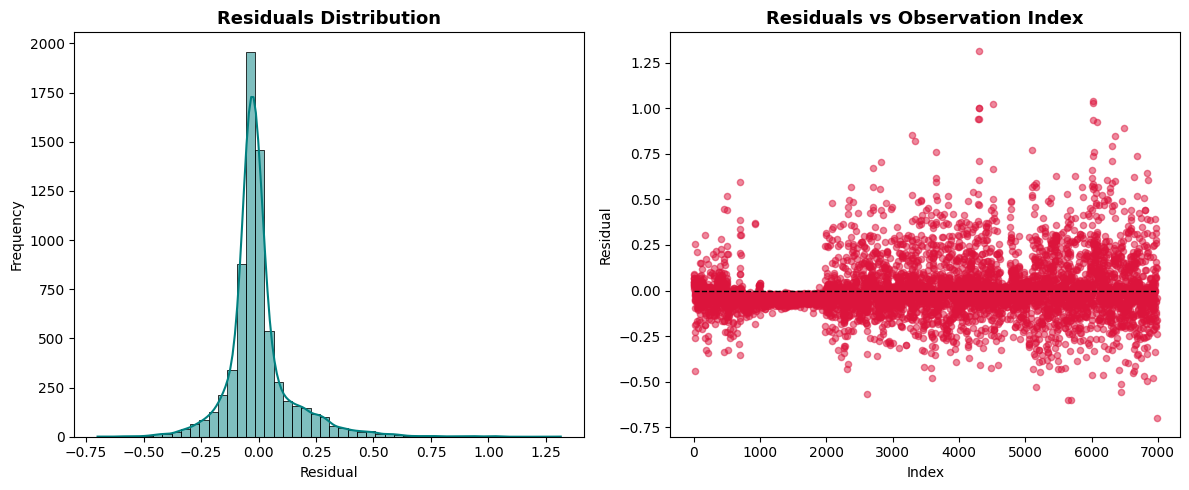

In [114]:
# PLOTTING THE RESIDUAL PLOT (sHOULD BE NORMAL)

residuals = y_test1 - xgb.predict(x_test1)

plt.figure(figsize=(12,5))

# Histogram with KDE
plt.subplot(1,2,1)
sns.histplot(residuals, bins=50, kde=True, color="teal")
plt.title("Residuals Distribution", fontsize=13, weight="bold")
plt.xlabel("Residual")
plt.ylabel("Frequency")

# Residuals vs Index scatter
plt.subplot(1,2,2)
plt.scatter(range(len(residuals)), residuals, alpha=0.5, color="crimson", s=20)
plt.hlines(0, 0, len(residuals), colors="black", linestyles="--", lw=1)
plt.title("Residuals vs Observation Index", fontsize=13, weight="bold")
plt.xlabel("Index")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()


# **RESULTS OF OUR MODELS**

In [115]:
import pandas as pd

results = {
    "Model"   : ["KNN" , "Random Forest" , "Gradient Boosting", "XGBoost"],
    "RMSE"    : [rmse_knn,  rmse_rf,  rmse_gb, rmse_xgb ],
    "MAE"     : [mae_knn,   mae_rf,   mae_gb,  mae_xgb   ],
    "R²"      : [r2_knn,    r2_rf,    r2_gb,   r2_xgb ],
    "Naive R²": [naive_r2, naive_r2, naive_r2, naive_r2 ]
}

df_results = pd.DataFrame(results)
print(df_results)

               Model      RMSE       MAE        R²  Naive R²
0                KNN  0.182266  0.115261  0.849019  0.638746
1      Random Forest  0.161749  0.026163  0.881096  0.638746
2  Gradient Boosting  0.140140  0.093192  0.902441  0.638746
3            XGBoost  0.141346  0.088207  0.909257  0.638746


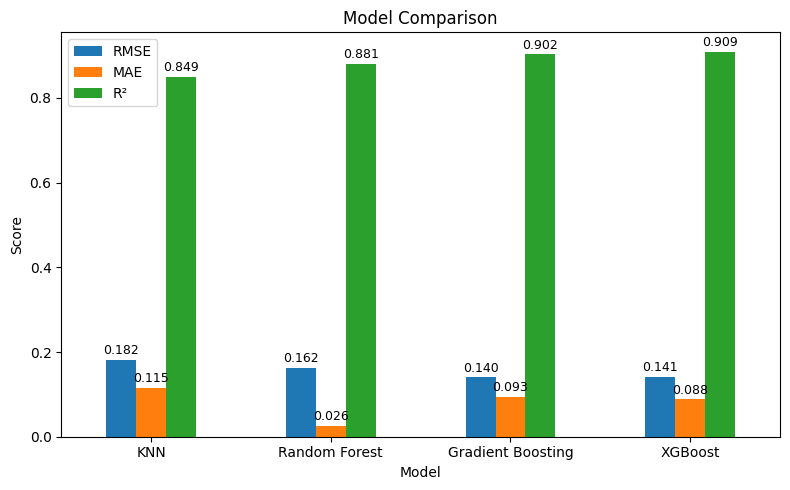

In [116]:
import matplotlib.pyplot as plt

ax = df_results.set_index("Model")[["RMSE","MAE","R²"]].plot(
    kind="bar", figsize=(8,5), rot=0
)

plt.title("Model Comparison")
plt.ylabel("Score")


for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", fontsize=9, padding=2)

plt.tight_layout()
plt.show()



# **CONCLUSION :**


---




The **Naive**  **R² = 0.64**, meaning that just using the previous value explains about 64% of the variation.





**KNN** improved this to **R²=0.85**, but it was less accurate compared to the other models.

**Random Forest** performed better with **R² = 0.88** and lower error.

**Gradient Boosting** gave even higher accuracy with **R² = 0.90**.

**XGBoost** was the **best** model, reaching **R² = 0.91** and the lowest errors.

# **Saving our models**

In [ ]:
import joblib


joblib.dump(knn, "knn_model.pkl")

joblib.dump(scaler, "knn_scaler.pkl")

joblib.dump(rf, "random_forest.pkl")

joblib.dump(gb, "gradient_boosting.pkl")

xgb.save_model("xgb_model.json")

joblib.dump(rf, "random_forest.pkl")


['random_forest.pkl']

In [ ]:
from google.colab import files

#Saving the Dataframes

df_copy.to_csv("df_knn.csv", index=False)
df_copy.to_csv("df_rf.csv", index=False)
df_copy.to_csv("df_gb.csv", index=False)
df_copy.to_csv("df_xgb.csv", index=False)




# Download THE Dataframes

files.download("df_knn.csv")
files.download("df_rf.csv")
files.download("df_gb.csv")
files.download("df_xgb.csv")

print("All Dataframes Dowloaded")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

All Dataframes Dowloaded
